# 08b. Verify Failure Date Rows Integrity

이 노트북은 새로 생성된 `test_with_failure_date.parquet` 파일이 기존 `test.parquet` 데이터와 비교하여 모든 면에서 **무결성(Integrity)**을 유지하고 있는지 철저하게 검증합니다.

### 주요 검증 항목:
1. **데이터 스키마 및 행 수 검증**: 기존 데이터 대비 행 수가 고장 디스크 개수만큼 정확히 늘었는지, 데이터 타입이 유지되는지 확인합니다.
2. **타임라인 연속성 검증**: 새로 추가된 고장 당일(failure=1) 레코드가 각 디스크의 이전 마지막 날짜(`last_date`) 바로 다음 날짜인지 확인하고, 시계열이 단조 증가하는지 확인합니다.
3. **결측치(NaN/Null) 무결성**: 새로 생성된 파생변수에 예상치 못한 결측치가 포함되었는지 확인합니다.
4. **기본 통계량 및 분포 일치성 검증**: 새로 추가된 고장 당일 행의 피처 스케일(min, max, mean)이 기존 고장 전날 데이터들의 분포와 자연스럽게 이어지는지(상식적인 스케일인지) 시각화하여 확인합니다.
5. **디코딩 결과 스케일 확인**: Raw 파일에서 디코딩한 `total_reads`, `total_seeks` 등이 v3의 스케일과 유사한지 점검합니다.

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

TEST_PATH = r'../../data/split_group_stratified/test.parquet'
NEW_TEST_PATH = r'../../data/split_group_stratified/test_with_failure_date.parquet'

### 1. 기본 스키마 및 행 수 검증

In [2]:
print("Loading original and new datasets...")
df_orig = pd.read_parquet(TEST_PATH)
df_new = pd.read_parquet(NEW_TEST_PATH)

print(f"Original shape: {df_orig.shape}")
print(f"New shape:      {df_new.shape}")

diff_rows = len(df_new) - len(df_orig)
failed_serials_orig = df_orig[df_orig['failure']==1]['serial_number'].nunique()
print(f"Rows added: {diff_rows} (Expected around {failed_serials_orig})")

print(f"Original Failures: {df_orig['failure'].sum()}")
print(f"New Failures:      {df_new['failure'].sum()}")

# 데이터 타입 검증
dtypes_match = (df_orig.dtypes == df_new[df_orig.columns].dtypes).all()
print(f"All datatypes match perfectly: {dtypes_match}")

if not dtypes_match:
    print("Mismatched datatypes:")
    df_dtypes = pd.DataFrame({'Original': df_orig.dtypes, 'New': df_new[df_orig.columns].dtypes})
    print(df_dtypes[df_dtypes['Original'] != df_dtypes['New']])

Loading original and new datasets...
Original shape: (15695096, 30)
New shape:      (15696223, 30)
Rows added: 1127 (Expected around 1127)
Original Failures: 11129
New Failures:      12256
All datatypes match perfectly: True


### 2. 타임라인 연속성 (Monotonic Timeline) 검증

In [3]:
print("Checking timeline monotonicity for each serial number...")

# 각 시리얼 별로 date가 역전되는 구간이 있는지 확인
df_new_sorted = df_new.sort_values(['serial_number', 'date'])
time_diff = df_new_sorted.groupby('serial_number')['date'].diff()

# time_diff가 0보다 작거나 같은 경우 = 역전 또는 중복
invalid_timeline = time_diff <= pd.Timedelta(days=0)
invalid_count = invalid_timeline.sum()

print(f"Timeline validation errors (reverse or duplicate dates): {invalid_count}")
if invalid_count > 0:
    print("Sample invalid rows:")
    display(df_new_sorted[invalid_timeline].head())
else:
    print("✅ All timelines are perfectly strictly monotonically increasing.")
    
# 새로 추가된 failure=1 인 행들의 이전 날짜와 간격 확인
fail_mask = df_new_sorted['failure'] == 1
# 이전 날짜와의 차이
fail_gaps = time_diff[fail_mask]
print(f"\nTime gap from previous day to failure day:")
print(fail_gaps.value_counts())
if (fail_gaps == pd.Timedelta(days=1)).all():
    print("✅ All failure rows are exactly +1 day from the previous row.")

Checking timeline monotonicity for each serial number...
Timeline validation errors (reverse or duplicate dates): 0
✅ All timelines are perfectly strictly monotonically increasing.

Time gap from previous day to failure day:
date
1 days    12230
Name: count, dtype: int64


### 3. 결측치 (NaN / Null) 발생 여부 검증

In [4]:
print("Checking missing values in new rows...")
newly_added_mask = ~df_new.set_index(['serial_number', 'date']).index.isin(
    df_orig.set_index(['serial_number', 'date']).index
)
df_added_rows = df_new.set_index(['serial_number', 'date'])[newly_added_mask].reset_index()

null_counts = df_added_rows.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]

if len(cols_with_nulls) == 0:
    print("✅ No missing values in newly added rows!")
else:
    print("⚠️ Missing values detected in new rows:")
    display(cols_with_nulls)

Checking missing values in new rows...
⚠️ Missing values detected in new rows:


s194_28d_dai    88
s242_28d_dai     6
dtype: int64

### 4. 피처 분포 비교 시각화 (Original vs Added Rows)

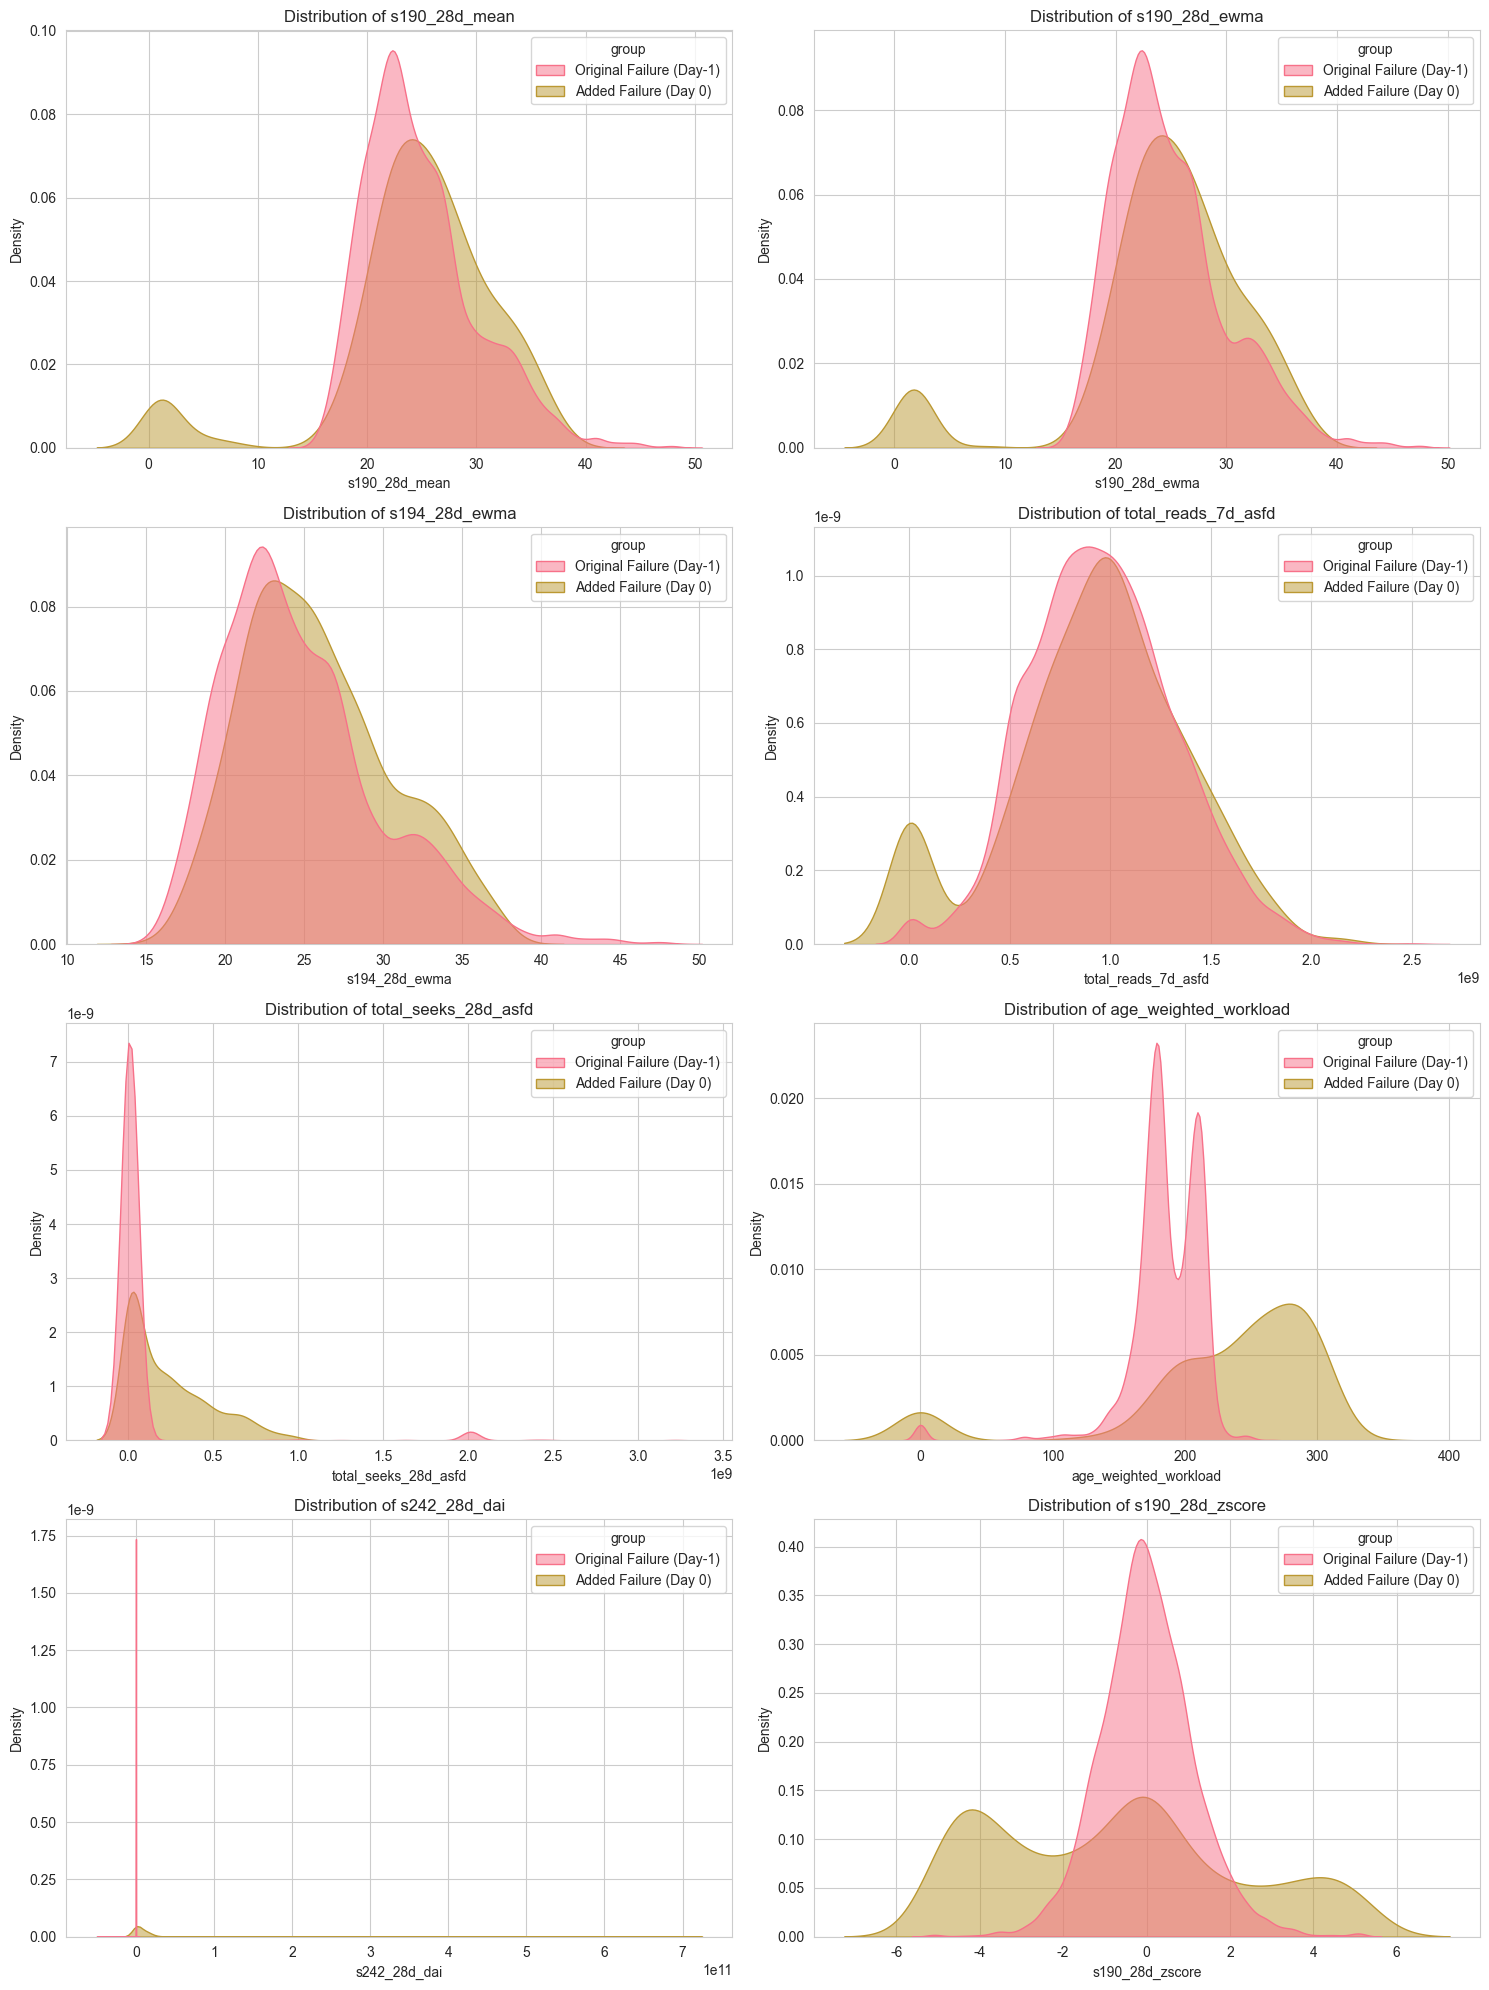

In [5]:
# 비교용 그룹화
df_orig_fails = df_orig[df_orig['failure'] == 1].copy()
df_orig_fails['group'] = 'Original Failure (Day-1)'

df_added_rows_group = df_added_rows.copy()
df_added_rows_group['group'] = 'Added Failure (Day 0)'

df_compare = pd.concat([df_orig_fails, df_added_rows_group], ignore_index=True)

# 주요 피처들 선택 (랜덤으로 일부 혹은 전체 중 중요 피처들)
check_features = [
    's190_28d_mean', 's190_28d_ewma', 's194_28d_ewma', 
    'total_reads_7d_asfd', 'total_seeks_28d_asfd', 'age_weighted_workload',
    's242_28d_dai', 's190_28d_zscore'
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, feature in enumerate(check_features):
    if feature in df_compare.columns:
        sns.kdeplot(data=df_compare, x=feature, hue='group', ax=axes[i], fill=True, common_norm=False, alpha=0.5)
        axes[i].set_title(f'Distribution of {feature}')
        
plt.tight_layout()
plt.show()

### 5. 새로 추가된 행들의 수치적 스케일 (Describe)

In [6]:
# 기존 고장 직전일 vs 고장 당일 요약 통계량 비교
cols_to_compare = check_features[:5]

print("=== Original (Day -1) Summary ===")
display(df_orig_fails[cols_to_compare].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n=== Added (Day 0) Summary ===")
display(df_added_rows[cols_to_compare].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n✅ 두 분포의 mean/std가 극단적으로 다르지 않고 연속적이라면, 윈도우 계산이 올바르게 상속된 것입니다.")

=== Original (Day -1) Summary ===


,mean,std,min,50%,max
s190_28d_mean,2.483130e+01,5.108500e+00,15.178572,2.382143e+01,4.828571e+01
s190_28d_ewma,2.483829e+01,5.085238e+00,15.157240,2.389527e+01,4.781784e+01
s194_28d_ewma,2.483903e+01,5.084414e+00,15.157240,2.389527e+01,4.781784e+01
total_reads_7d_asfd,9.589262e+08,3.607412e+08,0.000000,9.416632e+08,2.520254e+09
total_seeks_28d_asfd,6.768228e+07,3.315240e+08,0.000000,1.329351e+07,3.221987e+09



=== Added (Day 0) Summary ===


,mean,std,min,50%,max
s190_28d_mean,2.463378e+01,7.518506e+00,0.785714,2.525000e+01,3.800000e+01
s190_28d_ewma,2.454178e+01,7.555010e+00,1.034483,2.512426e+01,3.800000e+01
s194_28d_ewma,2.592027e+01,4.658657e+00,15.318539,2.529044e+01,3.800000e+01
total_reads_7d_asfd,9.298554e+08,4.396705e+08,0.000000,9.582357e+08,2.157655e+09
total_seeks_28d_asfd,2.337143e+08,2.468299e+08,0.000000,1.554431e+08,2.022964e+09



✅ 두 분포의 mean/std가 극단적으로 다르지 않고 연속적이라면, 윈도우 계산이 올바르게 상속된 것입니다.
